In [17]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv

In [18]:
load_dotenv()

True

In [19]:
import os

llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    api_key=os.getenv("GEMINI_API_KEY"),
    max_tokens=1000
)

In [20]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [21]:
def get_text(content) -> str:
    """Return plain text whether content is a string or a list of blocks."""
    if isinstance(content, str):
        return content
    return "".join(
        b.get("text", "")
        for b in content
        if isinstance(b, dict) and b.get("type") == "text"
    )


In [22]:
def prompt_node(state: State):
    response = llm.invoke(state["messages"])
    # Store plain text so the block metadata isn't saved in the history
    return {"messages": [AIMessage(content=get_text(response.content))]}

In [23]:
graph = StateGraph(State)
graph.add_node("prompt", prompt_node)
graph.add_edge(START, "prompt")
graph.add_edge("prompt", END)

workflow = graph.compile(checkpointer=MemorySaver())

config = {"configurable": {"thread_id": "1"}}


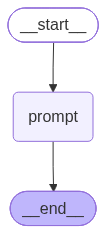

In [24]:
workflow

In [25]:
while True:
    user_message = input("You: ").strip()

    if user_message.lower() in ["exit", "quit", "bye"]:
        break
    if not user_message:
        continue

    response = workflow.invoke(
        {"messages": [HumanMessage(content=user_message)]},
        config=config,
    )
    print("AI:", get_text(response["messages"][-1].content))

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


AI: Hello! How can I help you today?
AI: I am Gemini, a large language model created by Google. How can I help you today?
